# Pipelines


## O que são pipelines?

Pipelines em Scikit-Learn facilitam a aplicação sequencial de uma série de transformações e um estimador final. Eles são úteis para encapsular todo o processo de pré-processamento e modelagem em um único objeto.

## Qual a estrutura de um pipeline?

Um pipeline é composto por etapas sequenciais, cada uma contendo um nome (string) e uma instância de transformador ou estimador. A última etapa deve ser um estimador. A estrutura pode ser vista como:



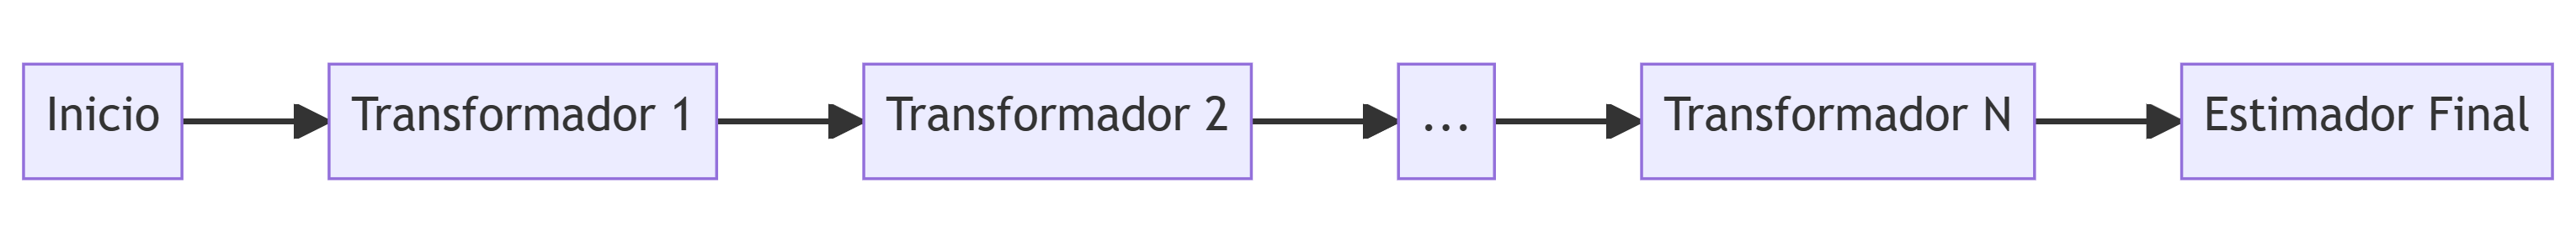

## Vantagens de usar pipeline

- **Conveniência**: Resume várias etapas em um único objeto.
- **Prevenção de vazamento de dados**: Garante que as informações do conjunto de teste não vazem para o conjunto de treinamento durante o ajuste e transformação.
- **Grid Search**: Facilita a pesquisa em grade através do espaço de hiperparâmetros.



A combinação de transformadores e estimadores em um único objeto através do uso de pipelines facilita o desenvolvimento, a compreensão e a manutenção do código de aprendizado de máquina. É uma prática recomendada especialmente para fluxos de trabalho mais complexos.

## Pipeline em um contexto mais amplo

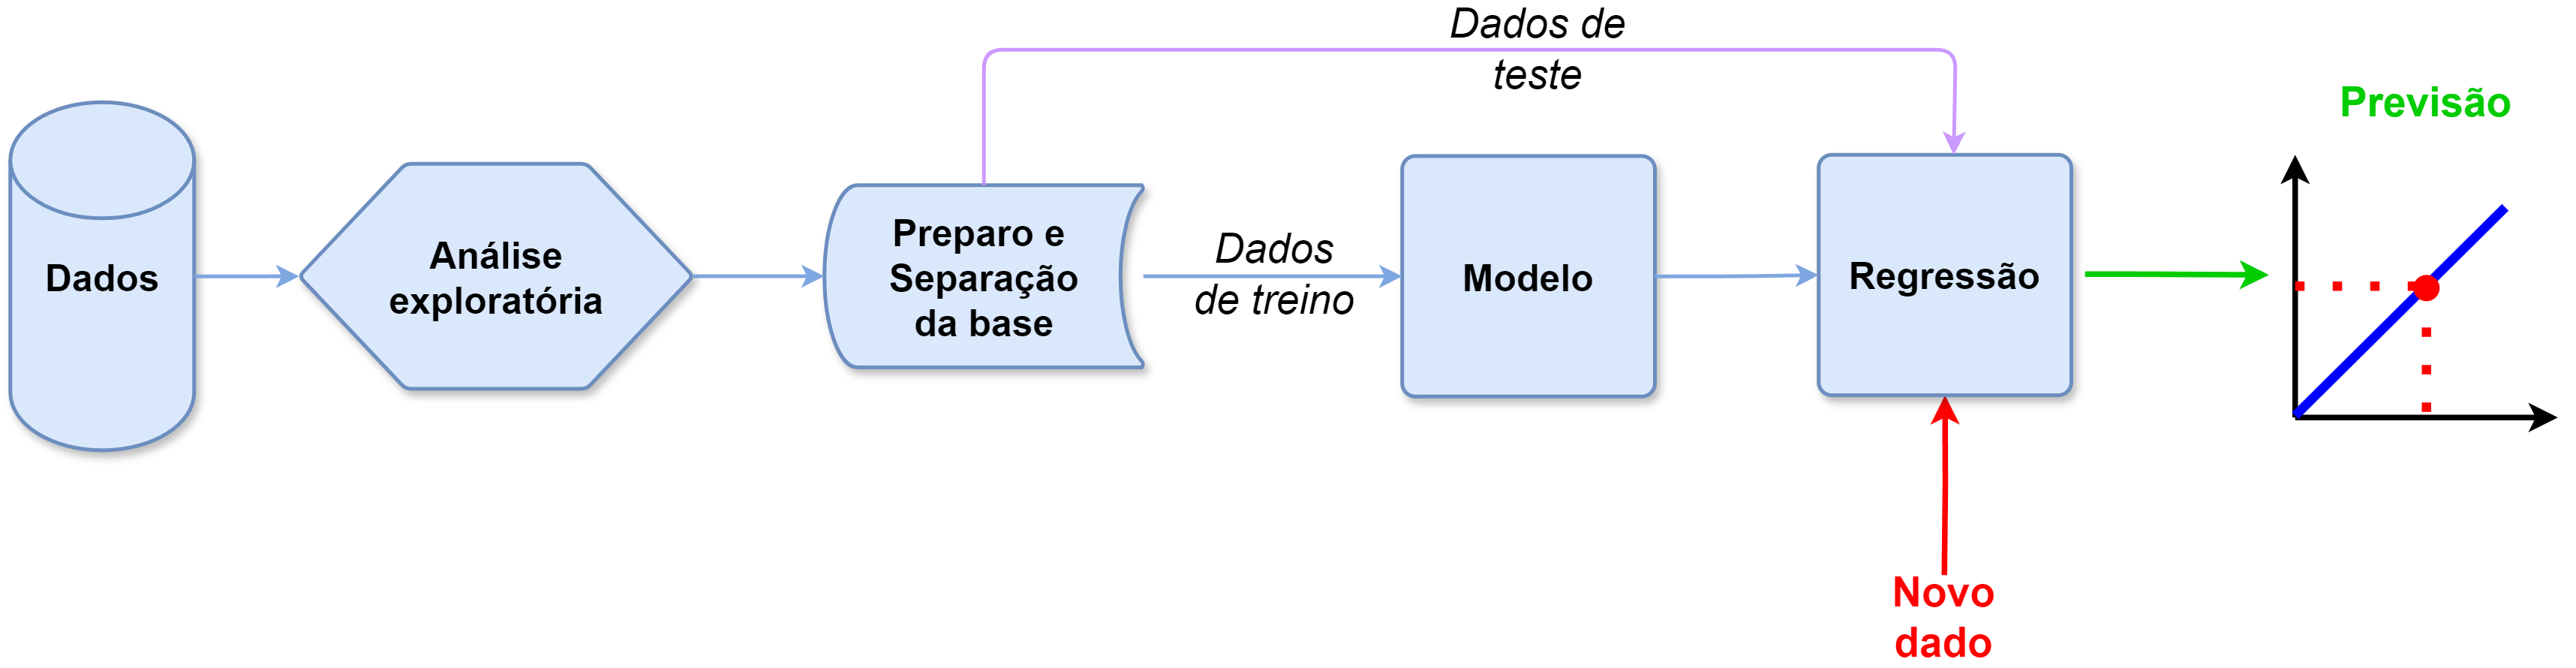

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_TRATADOS
from src.graficos import plot_coeficientes, plot_residuos

sns.set_theme(palette="bright")

RANDOM_STATE = 42

In [6]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [9]:
X = df.drop(columns="target")
y = df["target"]

In [ ]:
#você percebe que a nossa base de dados tem varias escalas diferentes.Precisamos fazer uma padronização

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = RANDOM_STATE
)#vamos separar o que é treino e teste
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),#ajuste de escala
        ("reg", LinearRegression())#modelo de aprendizado
    ]
)

In [12]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [13]:
pipeline.score(X_test, y_test)

0.45260268449783325

In [14]:
pipeline.named_steps #Esse é um atributo do pipeline que mostra o passo a passo que foi feito 

{'scaler': StandardScaler(), 'reg': LinearRegression()}

In [15]:
pipeline["reg"].coef_ #Agora esses resultados estão dentro do dicionario do pipeline

array([  1.7537485, -11.511825 ,  25.607117 ,  16.828897 , -44.44891  ,
        24.640982 ,   7.6769967,  13.138806 ,  35.1612   ,   2.3513703],
      dtype=float32)

In [16]:
pipeline["reg"].intercept_

np.float32(153.73654)

In [18]:
coefs = dataframe_coeficientes(
    pipeline["reg"].coef_,
    X.columns
)

coefs

,coeficiente
colesterol_total,-44.448910
sexo,-11.511825
idade,1.753749
glicose,2.351370
hdl,7.676997
colesterol_hdl,13.138806
pressao_media,16.828897
ldl,24.640982
imc,25.607117
triglicerides,35.161201


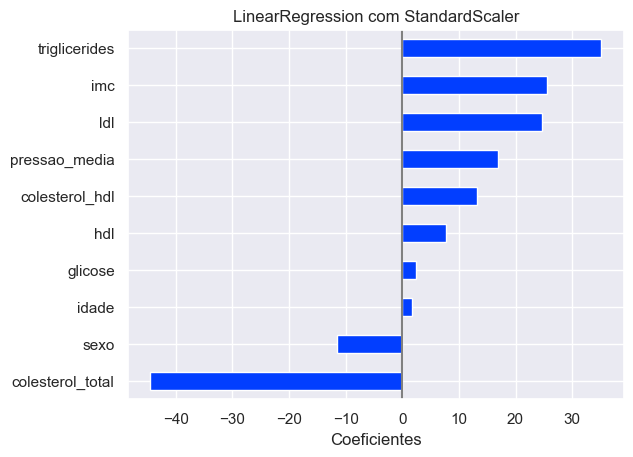

In [20]:
plot_coeficientes(coefs, "LinearRegression com StandardScaler")

In [ ]:
#Você percebeu que quandop ajustou a escala os coeficientes teve uma mudança significativa do modelo

In [21]:
pipeline["scaler"]

,copy,True
,with_mean,True
,with_std,True


In [23]:
X

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose
0,59,2,32.099998,101.000000,157,93.199997,38.0,4.00,4.8598,87
1,48,1,21.600000,87.000000,183,103.199997,70.0,3.00,3.8918,69
2,72,2,30.500000,93.000000,156,93.599998,41.0,4.00,4.6728,85
3,24,1,25.299999,84.000000,198,131.399994,40.0,5.00,4.8903,89
4,50,1,23.000000,101.000000,192,125.400002,52.0,4.00,4.2905,80
...,...,...,...,...,...,...,...,...,...,...
437,60,2,28.200001,112.000000,185,113.800003,42.0,4.00,4.9836,93
438,47,2,24.900000,75.000000,225,166.000000,42.0,5.00,4.4427,102
439,60,2,24.900000,99.669998,162,106.599998,43.0,3.77,4.1271,95
440,36,1,30.000000,95.000000,201,125.199997,42.0,4.79,5.1299,85


In [22]:
pipeline["scaler"].transform(X)#Esse tipo codigo não estou alterando os valores da variavel X e sim estou vendo o quanto que mudou utlizando o ajuste de escala na variavel X

array([[ 0.7917738 ,  1.0613699 ,  1.2701279 , ..., -0.06221033,
         0.3913575 , -0.4043973 ],
       [-0.0718379 , -0.9421786 , -1.127127  , ..., -0.8354584 ,
        -1.4561754 , -1.9476647 ],
       [ 1.8124058 ,  1.0613699 ,  0.9048321 , ..., -0.06221033,
         0.03444809, -0.57587147],
       ...,
       [ 0.87028396,  1.0613699 , -0.37370417, ..., -0.24005738,
        -1.0070797 ,  0.2814994 ],
       [-1.0139598 , -0.9421786 ,  0.79067713, ...,  0.54865557,
         0.9068729 , -0.57587147],
       [-1.0139598 , -0.9421786 , -1.5837471 , ..., -0.8354584 ,
        -0.11385107,  0.02428813]], shape=(442, 10), dtype=float32)

In [ ]:
#Vamos criar uma variavel para fazer um grafico sobre isso

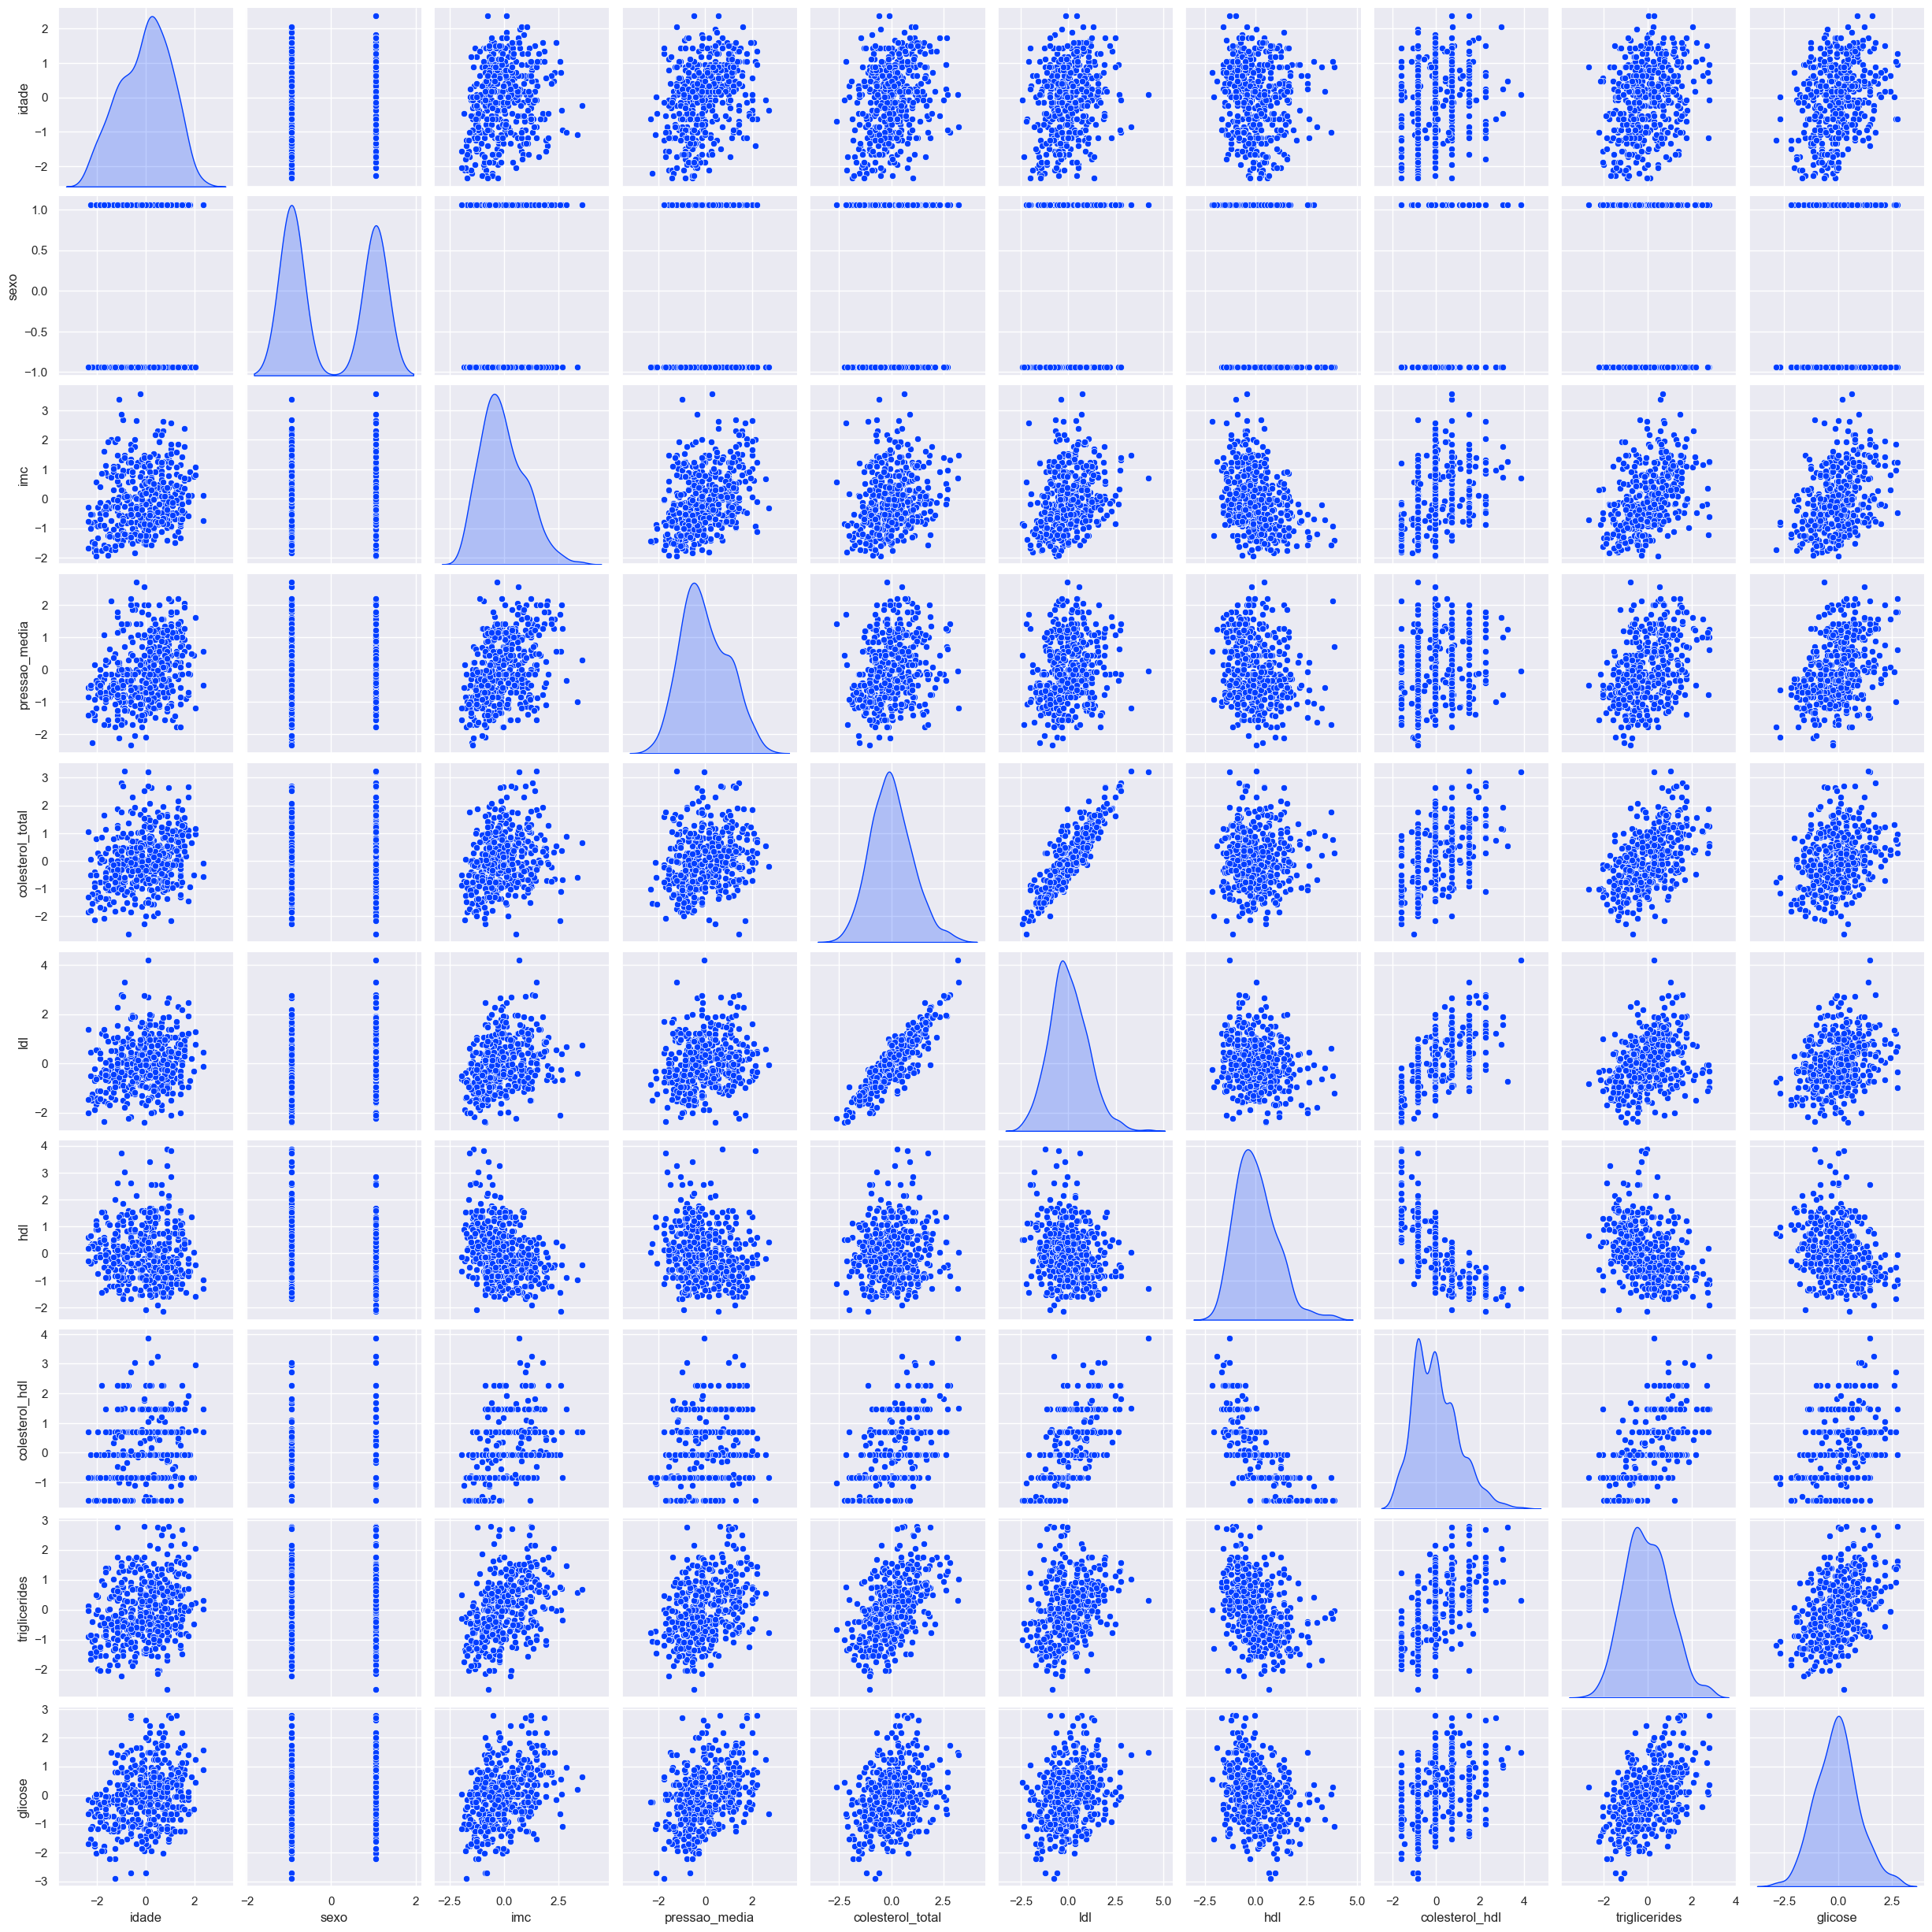

In [24]:
X_scaled = pipeline["scaler"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns =  X.columns)

sns.pairplot(X_scaled, diag_kind = "kde")

In [25]:
X_scaled.mean()

idade              -0.031162
sexo               -0.003865
imc                -0.036766
pressao_media      -0.024367
colesterol_total    0.011641
ldl                 0.016946
hdl                 0.021053
colesterol_hdl     -0.007891
triglicerides      -0.025462
glicose            -0.039142
dtype: float32

In [26]:
X_scaled.std()

idade               1.029192
sexo                1.000896
imc                 1.008701
pressao_media       0.983864
colesterol_total    0.997925
ldl                 1.001164
hdl                 1.013668
colesterol_hdl      0.997839
triglicerides       0.997039
glicose             0.985662
dtype: float32

In [ ]:
#Você percebe que esse valores estão bem proximos isso acontece com o ajuste que o scaled fez para agrupar os dadose ele esta fazendo o calculo do Zscore que é z = (X - media) / variancia e agora todas as nossas fetures estão na mesma escala

In [ ]:
#E com isso esses coeficientes ficam cada vez mais confiaveis com o avanço da doença.

In [ ]:
#Avaliando métricas

In [28]:
y_pred = pipeline.predict(X_test)

In [29]:
mean_absolute_error(y_test, y_pred)

42.794097900390625

In [30]:
mean_squared_error(y_test, y_pred)

2900.194091796875

In [31]:
root_mean_squared_error(y_test, y_pred)

53.853450775146484

In [32]:
r2_score(y_test, y_pred)

0.45260268449783325

In [ ]:
#Você percebeu que as metricas não mudaram comparando o mesmo teste que fizemos antes do ajuste de escala porem os coeficientes mudaram e com isso para avaliação fica melhor interpretar quais são as fetures aumentam o grau da doença

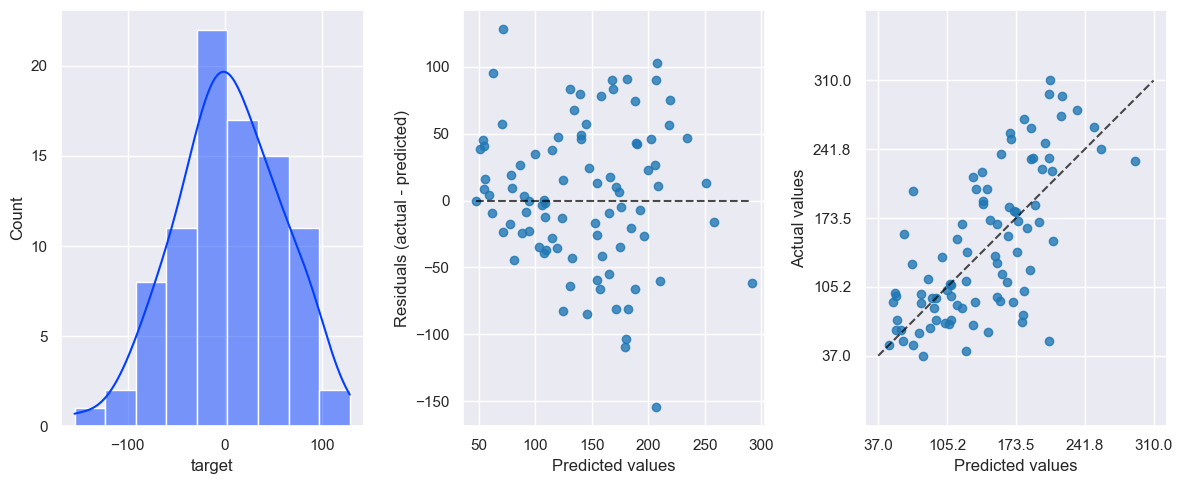

In [33]:
plot_residuos(y_test, y_pred)